# PROJECT 3
by Szymon Waliczek
 - Impact of spatial quantization and transverse confinement on 2DEG electron transport in **InAs**
 - Normal wire with leads and wraparound system
 - **No spin**
 - With Peierls phase - **QHE**

In [ ]:
import ipyparallel as ipp
cluster = ipp.Client(profile  = "kwant_parallel")
v = cluster[:]
lview = cluster.load_balanced_view()
len(v)

In [ ]:
%%px --local

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import kwant
import numpy as np

In [ ]:
from scipy.sparse.linalg import eigs
from matplotlib import pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [ ]:
%%px --local

# Physical constants
from scipy.constants import physical_constants
eV = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]
h_bar = physical_constants['Planck constant over 2 pi'][0]
phi_0 = physical_constants['elementary charge over h-bar'][0]
a = 5
m_eff = 0.023 * m_el
t = (h_bar**2 / (2 * m_eff * (a*1e-9)**2)) / eV # hopping in eV
W, L = 100, 200
freedom_deg = 1; # No spins
PI = np.pi

In [ ]:
print(f"h_bar = {h_bar}")
print(f"phi_0 = {phi_0}")
print(f"m_eff = {m_eff}")
print(f"a = {a}")
print(f"t = {t}")
print(f"W, L = {W, L}")

In [ ]:
%%px --local

def rectangle_inf(pos, width):
    (x, y) = pos
    return abs(x) < width/2
#-----------------------------------------------------------------------
def rectangle(pos, width, length):
    (x, y) = pos
    return abs(x) < width/2 and abs(y) < length/2
def onsite(site, mu):
    return 4*t - mu
#-----------------------------------------------------------------------
def hop(site1, site2, alpha, B):
    x1, y1 = site1.pos
    x2, y2 = site2.pos
    dx, dy = site1.pos - site2.pos
    # Faza Peierlsa Gauge A = [0, Bx, 0])
    p_phase = np.exp(-1j *phi_0*B*(x1+x2)/2*(y1 - y2)*1e-18)
    
    if abs(dx) > 0.5 * a:
        return -t * 1.0
    if abs(dy) > 0.5 * a:
        return -t * p_phase
#-----------------------------------------------------------------------
def make_sys_wrapped(a, width):
    lat = kwant.lattice.square(a, norbs = freedom_deg)
    sym_y = kwant.TranslationalSymmetry((0, a))
    sys = kwant.Builder(sym_y) 
    sys[lat.shape(lambda p: rectangle_inf(p, width), (0, 0))] = onsite
    sys[lat.neighbors(1)] = hop
    wrapped = kwant.wraparound.wraparound(sys, coordinate_names='y').finalized()
    return wrapped
#-----------------------------------------------------------------------
def make_sys_fine(a, width, length):
    lat = kwant.lattice.square(a, norbs = freedom_deg)
    sys = kwant.Builder()
    sys[lat.shape(lambda p: rectangle(p, width, length), (0, 0))] = onsite
    sys[lat.neighbors(1)] = hop
    return sys, lat
#-----------------------------------------------------------------------
def lead_shape(pos, width):
    return abs(pos[0]) < width / 2
#-----------------------------------------------------------------------
def make_lead(sys, lat, a, width):
    lead = kwant.Builder(kwant.TranslationalSymmetry((0, a)))
    lead[lat.shape(lambda p: lead_shape(p, width), (0, 0))] = onsite
    lead[lat.neighbors()] = hop
    sys.attach_lead(lead)           # Lead 0
    sys.attach_lead(lead.reversed()) # Lead 1

In [ ]:
def plot_sys(sys): # Plot system
    kwant.plot(sys, fig_size=(2, 3.5), show=False)
    plt.title(f"Lattice InAs (a = {a}nm)") 
    plt.xlabel("x [nm]")
    plt.ylabel("y [nm]")
    plt.show()

In [ ]:
%%px --local

wrapped = make_sys_wrapped(a, W)
sys_fine, lat_fine = make_sys_fine(a, W, L)
make_lead(sys_fine, lat_fine, a, W)
fsys = sys_fine.finalized()

In [ ]:
plot_sys(wrapped)
plot_sys(fsys)

In [ ]:
def eigen(sys, mu, B, modes):
    k_range = np.linspace(-PI/a, PI/a, 200)
    E, V = [], []
    for i in k_range:
        p = dict(mu=mu, B=B, alpha=0, k_y=i)
        ham = sys.hamiltonian_submatrix(params=p, sparse=True)
        eval, evec = eigs(ham, k=modes, sigma=0, which='LM')
        idx = eval.real.argsort()
        E.append(eval[idx].real)
        V.append(evec[:, idx])
    E = np.array(E)
    V = np.array(V)
    return E, k_range, V

In [ ]:
def plot_bands(E, k_range, ymin, ymax, xlim, modes):
    plt.figure(figsize=(4,3))
    for i in range(modes):
        plt.plot(k_range / (a), E[:, i], lw=1)  
    plt.title("Band structure")
    plt.ylabel("Energy [eV]")
    plt.xlabel("$k_y [1/nm]$")
    plt.ylim(ymin,ymax)
    plt.xlim((-xlim) / (a), (xlim) / (a))
    plt.grid(True)
    plt.show()   

In [ ]:
Eval, k, Evec = eigen(wrapped, mu=0, B=0, modes=2)
plot_bands(E=Eval, k_range=k, ymin = 0, ymax=0.02, xlim=PI, modes=2)

**Landau levels**

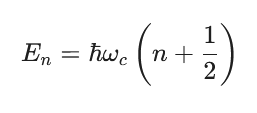

In [ ]:
Eval, k, Evec = eigen(wrapped, mu=0, B=5, modes=5)
plot_bands(E=Eval, k_range=k, ymin=0, ymax=0.2, xlim=PI, modes=5)

In [ ]:
Eval, k, Evec = eigen(wrapped, mu=0.1, B=0, modes=5)
plot_bands(E=Eval, k_range=k, ymin = -0.05, ymax=0.05, xlim=PI, modes=5)

In [ ]:
def plot_wrapped_density(sys, E, V, k_range, E0):
    diff = np.abs(E - E0)
    ky_idx, band_idx = np.unravel_index(diff.argmin(), E.shape)
    psi = V[ky_idx, :, band_idx]
    wf_density = np.abs(psi)**2
    kwant.plotter.map(sys, wf_density, fig_size=(5, 3), show=False)
    plt.title(f"E = {E[ky_idx, band_idx]:.6f} eV | $k_y$ = {k_range[ky_idx]:.3f}")
    plt.xlabel("$x$ [$nm$]")
    plt.show()

In [ ]:
Eval, k, Evec = eigen(wrapped, mu=0.01, B=0.5, modes=10)
plot_wrapped_density(wrapped, Eval, Evec, k_range=k, E0=0.002)

In [ ]:
def plot_conductance(sys, Eb, Ef, n, mu, B):
    energies = np.linspace(Eb, Ef, n)
    transmissions = []
    params = dict(mu=mu, alpha=0, B=B)
    for E in energies:
        smatrix = kwant.smatrix(sys, E, params=params)
        transmissions.append(smatrix.transmission(1, 0))

    plt.figure(figsize=(3, 3))
    plt.plot(energies, transmissions, lw=1)
    plt.title(f"Conductance | B = {B} T") 
    plt.xlabel("Energy $E$ [eV]")
    plt.ylabel("Conductance $G$ [$e^2/h$]")
    plt.grid(True)
    plt.show()

**Odd values of conductance - no **

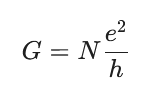

In [ ]:
plot_conductance(fsys, 0, 0.05, 100, mu=0.0, B=0.0)

In [ ]:
def plot_prob_density(sys, energies, mu, B):
    n = len(energies)
    params = dict(mu=mu, alpha=0, B=B)
    
    plt.figure(figsize=(5, 3))
    for i, E in enumerate(energies):
        wf = kwant.wave_function(sys, energy=E, params=params)(0)        
        if len(wf) > 0:
            ax = plt.subplot(1, n, i + 1)
            d_map = sum(kwant.operator.Density(sys)(p) for p in wf)
            kwant.plotter.map(sys, d_map, ax=ax, show=False)
        
            plt.title(f"E = {E} eV")
            plt.xlabel("x [nm]")
            plt.ylabel("y [nm]")
        else:
            print(f"No open chanels for E = {E} eV.")
            
    plt.tight_layout()
    plt.show()

In [ ]:
E = [0.002, 0.01, 0.02]

In [ ]:
plot_prob_density(fsys, E, mu=0, B=0)

In [ ]:
plot_prob_density(fsys, E, mu=0.01, B=0)

**Edge States** 
- The effective potential creates a harmonic trap centered at x0​,
  where the term Vconf​(x) forces a steep energy increase at the wire boundaries.
- This confinement prevents electrons from completing full cyclotron orbits, instead compelling them to "bounce" along the edges in skipping orbits.

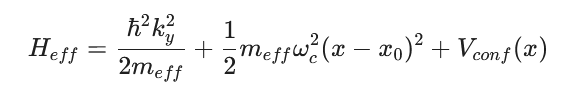

In [ ]:
plot_prob_density(fsys, E, mu=0, B=1)

In [ ]:
plot_prob_density(fsys, E, mu=0.003, B=1)